# Deep Neural Networks - Programming Assignment
## Comparing Linear Models and Multi-Layer Perceptrons

**Student Name:** ___________________  
**Student ID:** ___________________  

**Student Name:** ___________________  
**Student ID:** ___________________  

**Student Name:** ___________________  
**Student ID:** ___________________  

**Student Name:** ___________________  
**Student ID:** ___________________  

**Date:** ___________________

---

## ⚠️ IMPORTANT INSTRUCTIONS

1. **Complete ALL sections** marked with `TODO`
2. **DO NOT modify** the `get_assignment_results()` function structure
3. **Track training time** for both models using `time.time()`\n
4. **Store loss_history** in both model classes
5. **Calculate ALL metrics** (accuracy, precision, recall, F1)
6. **Fill get_assignment_results()** with ALL required fields
7. **PRINT the results** - Auto-grader needs visible output!
8. **Run all cells** before submitting (Kernel → Restart & Run All)

**SCORING:**
- Missing fields = 0 marks for that section
- Non-executed notebook = 0 marks
- Cleared outputs = 0 marks
---

DNN Assignment 1

Submitted by: KV GAUTHAMI

Student ID: 2026AK05157

In [11]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import time
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)
print('✓ Libraries imported successfully')

✓ Libraries imported successfully


## Section 1: Dataset Selection and Loading

**Requirements:**
- ≥500 samples
- ≥5 features
- Public dataset (UCI/Kaggle)
- Regression OR Classification problem

In [12]:
# TODO: Load your dataset
# Load the Superconductivity dataset (UCI ML Repository, id=464)

import os
from ucimlrepo import fetch_ucirepo

#fetch dataset
superconductivity_data = fetch_ucirepo(id=464)

data = pd.concat([superconductivity_data.data.features,
                  superconductivity_data.data.targets], axis=1)

# Dataset information (TODO: Fill these)
# Dataset information
dataset_name = "Superconductivity Data"
dataset_source = "UCI ML Repository (id=464)"
n_samples = data.shape[0]        # Total number of rows
n_features = data.shape[1] - 1   # Number of features (excluding target)
problem_type = "regression"

# Problem statement (TODO: Write 2-3 sentences)
problem_statement = """
This dataset has 81 features derived from the elemental composition of about 21,000
superconducting materials. The goal is to predict the critical temperature (Tc) - the
temperature below which the material becomes superconducting. Good predictions can
speed up materials research by helping narrow down promising chemical compositions for
high-temperature superconductors before actually synthesizing and testing them in a lab.
"""

# Primary evaluation metric (TODO: Fill this)
primary_metric = "rmse"

# Metric justification (TODO: Write 2-3 sentences)
metric_justification = """
This is a regression task with the target measured in Kelvin, so RMSE reports the
typical prediction error in the same physical units, which is directly interpretable
for materials scientists. It also penalises large errors more heavily than MAE, which
matters because badly mis-estimating Tc would waste experimental effort. We report
R-squared alongside it to capture the proportion of variance the model explains.
"""

print(f"Dataset: {dataset_name}")
print(f"Source: {dataset_source}")
print(f"Samples: {n_samples}, Features: {n_features}")
print(f"Problem Type: {problem_type}")
print(f"Primary Metric: {primary_metric}")

print("\nData Overview:")
data.head()

Dataset: Superconductivity Data
Source: UCI ML Repository (id=464)
Samples: 21263, Features: 81
Problem Type: regression
Primary Metric: rmse

Data Overview:


,number_of_elements,mean_atomic_mass,wtd_mean_atomic_mass,gmean_atomic_mass,wtd_gmean_atomic_mass,entropy_atomic_mass,wtd_entropy_atomic_mass,range_atomic_mass,wtd_range_atomic_mass,std_atomic_mass,...,wtd_mean_Valence,gmean_Valence,wtd_gmean_Valence,entropy_Valence,wtd_entropy_Valence,range_Valence,wtd_range_Valence,std_Valence,wtd_std_Valence,critical_temp
0,4,88.944468,57.862692,66.361592,36.116612,1.181795,1.062396,122.90607,31.794921,51.968828,...,2.257143,2.213364,2.219783,1.368922,1.066221,1,1.085714,0.433013,0.437059,29.0
1,5,92.729214,58.518416,73.132787,36.396602,1.449309,1.057755,122.90607,36.161939,47.094633,...,2.257143,1.888175,2.210679,1.557113,1.047221,2,1.128571,0.632456,0.468606,26.0
2,4,88.944468,57.885242,66.361592,36.122509,1.181795,0.975980,122.90607,35.741099,51.968828,...,2.271429,2.213364,2.232679,1.368922,1.029175,1,1.114286,0.433013,0.444697,19.0
3,4,88.944468,57.873967,66.361592,36.119560,1.181795,1.022291,122.90607,33.768010,51.968828,...,2.264286,2.213364,2.226222,1.368922,1.048834,1,1.100000,0.433013,0.440952,22.0
4,4,88.944468,57.840143,66.361592,36.110716,1.181795,1.129224,122.90607,27.848743,51.968828,...,2.242857,2.213364,2.206963,1.368922,1.096052,1,1.057143,0.433013,0.428809,23.0


## Section 2: Data Preprocessing

Preprocess your data:
1. Handle missing values
2. Encode categorical variables
3. Split into train/test sets
4. Scale features

In [13]:
# 1. Separate features (X) and target (y)
X = data.drop('critical_temp', axis=1).values
y = data['critical_temp'].values

# 2. Handle missing values 
if np.isnan(X).any():
    col_means = np.nanmean(X, axis=0)
    nan_idx = np.where(np.isnan(X))
    X[nan_idx] = np.take(col_means, nan_idx[1])

# 3. No categorical variables - all 81 features are numeric
print(superconductivity_data.variables) 


# Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
print("Data successfully split into 80% training and 20% testing sets.")

# 4a. Feature scaling: standardise inputs 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Input features standardized using StandardScaler.")

# 4b. Target scaling: standardise Tc so the from-scratch gradient descent is
#     numerically stable at the fixed learning rate. Predictions are mapped back
#     to Kelvin before any metric is computed, so all reported errors stay in
#     physical units.
y_mean, y_std = y_train.mean(), y_train.std()
y_train_scaled = (y_train - y_mean) / y_std
y_test_scaled = (y_test - y_mean) / y_std
print("Target variable (Tc) standardized to ensure numerical stability during gradient descent.")

# Fill these after preprocessing
train_samples = X_train.shape[0]        # Number of training samples
test_samples = X_test.shape[0]          # Number of test samples
train_test_ratio = train_samples / n_samples   # e.g. 0.8 for an 80-20 split

print(f"Train samples: {train_samples}")
print(f"Test samples: {test_samples}")
print(f"Split ratio: {train_test_ratio:.1%}")
print(f"Scaled feature matrix (train): {X_train_scaled.shape}")
print(f"Target range (Kelvin): {y.min():.1f} to {y.max():.1f}")

                     name     role        type demographic description units  \
0      number_of_elements  Feature     Integer        None        None  None   
1        mean_atomic_mass  Feature  Continuous        None        None  None   
2    wtd_mean_atomic_mass  Feature  Continuous        None        None  None   
3       gmean_atomic_mass  Feature  Continuous        None        None  None   
4   wtd_gmean_atomic_mass  Feature  Continuous        None        None  None   
..                    ...      ...         ...         ...         ...   ...   
77          range_Valence  Feature     Integer        None        None  None   
78      wtd_range_Valence  Feature  Continuous        None        None  None   
79            std_Valence  Feature  Continuous        None        None  None   
80        wtd_std_Valence  Feature  Continuous        None        None  None   
81          critical_temp   Target     Integer        None        None  None   

   missing_values  
0              no  

#### EDA 

In [14]:

# ============ Exploratory Data Analysis ============

print("="*60); print("\nEXPLORATORY DATA ANALYSIS\n"); print("="*60)

print(f"\nShape: {data.shape[0]} rows x {data.shape[1]} columns "
      f"({data.shape[1]-1} features + 1 target)")

# Data types
print("\nData types:",
      {str(k): int(v) for k, v in data.dtypes.value_counts().items()})

# Missing values and duplicates
print(f"Total missing values: {int(data.isna().sum().sum())}")
#print(f"Duplicate rows: {int(data.duplicated().sum())}")

# Descriptive statistics (first 6 features + target)
print("\nDescriptive statistics (first 6 features + target):")
desc = data.describe().T[['mean', 'std', 'min', '50%', 'max']]
#print(pd.concat([desc.round(3)]))
print(desc.round(3))

# Range (max - min) span per column: widest 3 and narrowest 3
span = (data.max() - data.min()).sort_values(ascending=False)
print("\nColumn value-range span (max - min)  |  widest 3 & narrowest 3:")
print(pd.concat([span.head(3), span.tail(3)]).round(3))

# Target summary
tc = data['critical_temp']
print(f"\nTarget 'critical_temp' (K): min={tc.min():.2f} max={tc.max():.2f} "
      f"mean={tc.mean():.2f} median={tc.median():.2f} std={tc.std():.2f}")

# Feature names:
print("\nFeature names:")
print(data.columns[:-1].tolist())


EXPLORATORY DATA ANALYSIS


Shape: 21263 rows x 82 columns (81 features + 1 target)

Data types: {'float64': 79, 'int64': 3}
Total missing values: 0

Descriptive statistics (first 6 features + target):
                         mean     std    min     50%      max
number_of_elements      4.115   1.439  1.000   4.000    9.000
mean_atomic_mass       87.558  29.676  6.941  84.923  208.980
wtd_mean_atomic_mass   72.988  33.490  6.423  60.697  208.980
gmean_atomic_mass      71.291  31.030  5.321  66.362  208.980
wtd_gmean_atomic_mass  58.540  36.651  1.961  39.918  208.980
...                       ...     ...    ...     ...      ...
range_Valence           2.041   1.242  0.000   2.000    6.000
wtd_range_Valence       1.483   0.978  0.000   1.063    6.992
std_Valence             0.839   0.485  0.000   0.800    3.000
wtd_std_Valence         0.674   0.456  0.000   0.500    3.000
critical_temp          34.421  34.254  0.000  20.000  185.000

[82 rows x 5 columns]

Column value-range span (max 

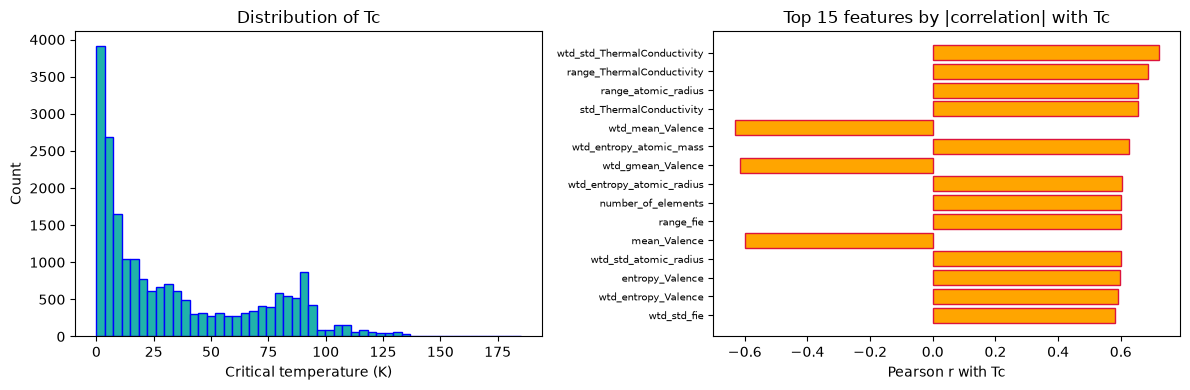

Feature pairs with |r| > 0.9
entropy_fie                entropy_atomic_radius      0.998
wtd_mean_Valence           wtd_gmean_Valence          0.995
entropy_fie                entropy_Valence            0.993
wtd_mean_fie               wtd_gmean_fie              0.992
mean_Valence               gmean_Valence              0.990
entropy_atomic_radius      entropy_Valence            0.990
range_ThermalConductivity  std_ThermalConductivity    0.988
range_FusionHeat           std_FusionHeat             0.985
range_fie                  std_fie                    0.982
wtd_mean_atomic_radius     wtd_gmean_atomic_radius    0.980
dtype: float64

Candidate columns with |r| > 0.9: 35 of 81

Distribution of target variable (Tc) : the target is bimodal (a low-Tc majority plus a high-Tc cuprate cluster near 90 K)


In [32]:
# ---- Correlation analysis ----
corr = data.corr()

# (1) Target distribution + strongest correlations with Tc
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(data['critical_temp'], bins=50, color='lightseagreen', edgecolor='blue')
plt.xlabel('Critical temperature (K)'); plt.ylabel('Count')
plt.title('Distribution of Tc')

plt.subplot(1, 2, 2)
tcorr = corr['critical_temp'].drop('critical_temp')
top = tcorr.reindex(tcorr.abs().sort_values(ascending=False).index).head(15)
plt.barh(range(len(top)), top.values, color='orange', edgecolor='crimson')
plt.yticks(range(len(top)), top.index, fontsize=7); plt.gca().invert_yaxis()
plt.xlabel('Pearson r with Tc'); plt.title('Top 15 features by |correlation| with Tc')
plt.tight_layout(); plt.show()


# (3) Highly correlated feature pairs (|r| > 0.9), target excluded
feat_corr = data.drop('critical_temp', axis=1).corr().abs()
upper = feat_corr.where(np.triu(np.ones(feat_corr.shape), k=1).astype(bool))
threshold = 0.9
high_pairs = upper.stack().loc[lambda s: s > threshold].sort_values(ascending=False)
print(f"Feature pairs with |r| > {threshold}") #: {len(high_pairs)}")
print(high_pairs.head(10).round(3))

# Candidate columns to drop: keep one from each correlated pair
to_drop = set()
for f1, f2 in high_pairs.index:
    if f1 not in to_drop:
        to_drop.add(f2)
print(f"\nCandidate columns with |r| > {threshold}: "
      f"{len(to_drop)} of {data.shape[1]-1}")

print("\nDistribution of target variable (Tc) : the target is bimodal (a low-Tc majority plus a high-Tc cuprate cluster near 90 K)")

# Reason for Dropping / Not dropping:

# TO BE FILLED

## Section 3: Baseline Model Implementation

Implement from scratch (NO sklearn models!):
- Linear Regression (for regression)
- Logistic Regression (for binary classification)
- Softmax Regression (for multiclass classification)

**Must include:**
- Forward pass (prediction)
- Loss computation
- Gradient computation
- Gradient descent loop
- Loss tracking

In [16]:
class BaselineModel:
    """
    A simple linear regression model trained with batch gradient descent on the MSE loss.
    """
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        self.loss_history = []

    def fit(self, X, y):
        n_samples, n_features = X.shape

        # Initialize parameters
        self.weights = np.zeros(n_features)
        self.bias = 0

        # Gradient descent loop
        for i in range(self.n_iterations):
            # Forward pass (prediction)
            y_pred = X @ self.weights + self.bias
            # MSE
            error = y_pred - y
            loss = np.mean(error ** 2)
            # Compute gradients
            dw = (2 / n_samples) * (X.T @ error)
            db = (2 / n_samples) * np.sum(error)
            # Update weights and bias
            self.weights -= self.lr * dw
            self.bias -= self.lr * db
            # Store loss
            self.loss_history.append(loss)

        return self

    def predict(self, X):
        return X @ self.weights + self.bias

print("✓ Baseline model class defined")

✓ Baseline model class defined


In [17]:
# Training baseline model
print("Training baseline model...")
baseline_start = time.time()

# Initialize and training
baseline_model = BaselineModel(learning_rate=0.01, n_iterations=1000)
baseline_model.fit(X_train_scaled, y_train_scaled)

# Predictions 
baseline_predictions = baseline_model.predict(X_test_scaled) * y_std + y_mean

baseline_training_time = time.time() - baseline_start
print(f"✓ Baseline training completed in {baseline_training_time:.2f}s")
print(f"✓ Loss decreased from {baseline_model.loss_history[0]:.4f} to {baseline_model.loss_history[-1]:.4f}")

# Store loss explicitly
baseline_initial_loss = float(baseline_model.loss_history[0])
baseline_final_loss = float(baseline_model.loss_history[-1])

Training baseline model...
✓ Baseline training completed in 0.62s
✓ Loss decreased from 1.0000 to 0.2953


## Section 4: Multi-Layer Perceptron Implementation

Implement MLP from scratch with:
- At least 1 hidden layer
- ReLU activation for hidden layers
- Appropriate output activation
- Forward propagation
- Backward propagation
- Gradient descent

In [18]:
class MLP:
    """
    Multi-Layer Perceptron implemented from scratch
    """
    def __init__(self, architecture, learning_rate=0.01, n_iterations=1000):
        self.architecture = architecture
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.parameters = {}
        self.loss_history = []
        self.cache = {}

    def initialize_parameters(self):
        np.random.seed(42)

        for l in range(1, len(self.architecture)):
            n_out, n_in = self.architecture[l], self.architecture[l - 1]
            self.parameters[f'W{l}'] = np.random.randn(n_out, n_in) * np.sqrt(2.0 / n_in)
            self.parameters[f'b{l}'] = np.zeros((n_out, 1))

    def relu(self, Z):
        """ReLU activation function"""
        return np.maximum(0, Z)

    def relu_derivative(self, Z):
        """ReLU derivative"""
        return (Z > 0).astype(float)

    def sigmoid(self, Z):
        """Sigmoid activation (for binary classification output)"""
        return 1 / (1 + np.exp(-np.clip(Z, -500, 500)))

    def forward_propagation(self, X):
        """
        Forward pass. X has shape (n_features, n_samples).
        Hidden layers use ReLU; the output layer is linear (regression).
        Z and A are cached at every layer for backpropagation.
        """
        self.cache['A0'] = X

        L = len(self.architecture) - 1
        A = X
        for l in range(1, L + 1):
            Z = self.parameters[f'W{l}'] @ A + self.parameters[f'b{l}']
            self.cache[f'Z{l}'] = Z
            A = self.relu(Z) if l < L else Z   # linear output for regression
            self.cache[f'A{l}'] = A
        return A

    def backward_propagation(self, X, y):
        m = X.shape[0]
        grads = {}
        y = y.reshape(1, -1)
        L = len(self.architecture) - 1

        # Output layer (linear activation)
        dZ = (2.0 / m) * (self.cache[f'A{L}'] - y)
        for l in range(L, 0, -1):
            grads[f'dW{l}'] = dZ @ self.cache[f'A{l - 1}'].T
            grads[f'db{l}'] = np.sum(dZ, axis=1, keepdims=True)
            if l > 1:  # propagate through the ReLU of the previous hidden layer
                dA_prev = self.parameters[f'W{l}'].T @ dZ
                dZ = dA_prev * self.relu_derivative(self.cache[f'Z{l - 1}'])

        return grads

    def update_parameters(self, grads):
        """Gradient-descent update for the weights and biases of every layer."""
        for l in range(1, len(self.architecture)):
            self.parameters[f'W{l}'] -= self.lr * grads[f'dW{l}']
            self.parameters[f'b{l}'] -= self.lr * grads[f'db{l}']

    def compute_loss(self, y_pred, y_true):
        """Mean squared error (regression)."""
        y_true = y_true.reshape(1, -1)
        return np.mean((y_pred - y_true) ** 2)

    def fit(self, X, y):
        """
        Training loop. Populates self.loss_history with the MSE per iteration.
        """
        self.initialize_parameters()

        X_T = X.T                    # work in (n_features, n_samples) convention
        y_row = y.reshape(1, -1)

        for i in range(self.n_iterations):
            # 1. Forward propagation
            y_pred = self.forward_propagation(X_T)
            # 2. Compute loss
            loss = self.compute_loss(y_pred, y_row)
            self.loss_history.append(loss)
            # 3. Backward propagation  (X kept as (m, features) so m = X.shape[0])
            grads = self.backward_propagation(X, y)
            # 4. Update parameters
            self.update_parameters(grads)

        return self

    def predict(self, X):
        return self.forward_propagation(X.T).flatten()

print("✓ MLP class defined")

✓ MLP class defined


In [19]:
# ============================================================
# MLP Hyperparameter Tuning  (model selection on a validation split)
# ============================================================
import itertools, time
from sklearn.model_selection import train_test_split

print("MLP HYPERPARAMETER TUNING\n")

# --- Carve a 15% validation set out of the TRAINING data ---
# Split the *unscaled* training features so the scaler can be refit on the
# sub-training portion only (fitting it on the validation rows would leak).
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.15, random_state=42)

tune_scaler = StandardScaler()
X_tr_s  = tune_scaler.fit_transform(X_tr)
X_val_s = tune_scaler.transform(X_val)
y_tr_mean, y_tr_std = y_tr.mean(), y_tr.std()
y_tr_s = (y_tr - y_tr_mean) / y_tr_std          # standardised target for GD

print(f"Sub-train: {X_tr_s.shape[0]} | Validation: {X_val_s.shape[0]} "
      f"| Test (untouched): {X_test_scaled.shape[0]}\n")

# --- Hyperparameter grid  ---
hidden_layer_configs = [[64, 32], [128, 64], [32, 16]]
learning_rates       = [0.01, 0.05]     
iteration_configs    = [1000, 2000, 4000]

best_val_rmse = float('inf')
best_params   = None

hdr = f"{'Hidden':<12} | {'LR':<5} | {'Iters':<6} | {'Time':<6} | {'Val RMSE'}"
print(hdr); print("-" * len(hdr))

for hidden_layers, lr, iters in itertools.product(
        hidden_layer_configs, learning_rates, iteration_configs):
    arch = [n_features] + hidden_layers + [1]

    t0 = time.time()
    model = MLP(architecture=arch, learning_rate=lr, n_iterations=iters)
    model.fit(X_tr_s, y_tr_s)
    dt = time.time() - t0

    # validation RMSE in Kelvin (map predictions back with sub-train stats)
    val_pred = model.predict(X_val_s) * y_tr_std + y_tr_mean
    val_rmse = np.sqrt(np.mean((y_val - val_pred) ** 2))

    flag = ""
    if not np.isfinite(val_rmse):
        val_rmse, flag = float('inf'), "  <- diverged"
    shown = "--" if np.isinf(val_rmse) else f"{val_rmse:.2f}"
    print(f"{str(hidden_layers):<12} | {lr:<5} | {iters:<6} | {dt:<5.0f}s | {shown}{flag}")

    if val_rmse < best_val_rmse:
        best_val_rmse = val_rmse
        best_params = {'architecture': arch, 'hidden_layers': hidden_layers,
                       'learning_rate': lr, 'n_iterations': iters}

print("-" * len(hdr))
print(f"Best on validation: {best_params['hidden_layers']}, "
      f"lr={best_params['learning_rate']}, iters={best_params['n_iterations']} "
      f"-> val RMSE {best_val_rmse:.2f} K")


final_model = MLP(architecture=best_params['architecture'],
                  learning_rate=best_params['learning_rate'],
                  n_iterations=best_params['n_iterations'])
final_model.fit(X_train_scaled, y_train_scaled)          # full 80% train
test_pred = final_model.predict(X_test_scaled) * y_std + y_mean
test_rmse = np.sqrt(np.mean((y_test - test_pred) ** 2))
print(f"\nFinal model test RMSE : {test_rmse:.2f} K")

MLP HYPERPARAMETER TUNING

Sub-train: 14458 | Validation: 2552 | Test (untouched): 4253

Hidden       | LR    | Iters  | Time   | Val RMSE
-------------------------------------------------
[64, 32]     | 0.01  | 1000   | 17   s | 16.10
[64, 32]     | 0.01  | 2000   | 34   s | 15.02
[64, 32]     | 0.01  | 4000   | 70   s | 14.23
[64, 32]     | 0.05  | 1000   | 18   s | 14.45
[64, 32]     | 0.05  | 2000   | 34   s | 13.83
[64, 32]     | 0.05  | 4000   | 70   s | 13.30
[128, 64]    | 0.01  | 1000   | 26   s | 15.64
[128, 64]    | 0.01  | 2000   | 53   s | 14.93
[128, 64]    | 0.01  | 4000   | 105  s | 14.16
[128, 64]    | 0.05  | 1000   | 26   s | 13.98
[128, 64]    | 0.05  | 2000   | 53   s | 13.18
[128, 64]    | 0.05  | 4000   | 105  s | 12.36
[32, 16]     | 0.01  | 1000   | 10   s | 16.07
[32, 16]     | 0.01  | 2000   | 19   s | 15.16
[32, 16]     | 0.01  | 4000   | 38   s | 14.37
[32, 16]     | 0.05  | 1000   | 10   s | 14.69
[32, 16]     | 0.05  | 2000   | 18   s | 14.04
[32, 16]    

In [20]:
# Train MLP
print("Training MLP...")
mlp_start_time = time.time()

# Use the best hyperparameters found by the tuning cell (from best_params)
mlp_architecture = best_params['architecture']
mlp_model = MLP(architecture=mlp_architecture,
                learning_rate=best_params['learning_rate'],
                n_iterations=best_params['n_iterations'])
mlp_model.fit(X_train_scaled, y_train_scaled)

# Make predictions (map back to Kelvin)
mlp_predictions = mlp_model.predict(X_test_scaled) * y_std + y_mean

mlp_training_time = time.time() - mlp_start_time
print(f"\u2713 Architecture={mlp_architecture}, lr={best_params['learning_rate']}, "
      f"iters={best_params['n_iterations']}")
print(f"\u2713 MLP training completed in {mlp_training_time:.2f}s")
print(f"\u2713 Loss decreased from {mlp_model.loss_history[0]:.4f} to {mlp_model.loss_history[-1]:.4f}")

# Store loss explicitly
mlp_initial_loss = float(mlp_model.loss_history[0])
mlp_final_loss = float(mlp_model.loss_history[-1])

Training MLP...
✓ Architecture=[81, 128, 64, 1], lr=0.05, iters=4000
✓ MLP training completed in 128.34s
✓ Loss decreased from 1.4618 to 0.1188


In [21]:
print("\nMLP Initial Loss: {:.2f}".format(mlp_initial_loss))
print("MLP Final Loss: {:.2f}".format(mlp_final_loss))

print("\nloss history (first 10) {}".format(mlp_model.loss_history[:10]))  # show first 10 loss values
print("\n")
print("\nloss history (last 10): {}".format(mlp_model.loss_history[-10:]))  # show last 10 loss values


MLP Initial Loss: 1.46
MLP Final Loss: 0.12

loss history (first 10) [np.float64(1.4618447071173042), np.float64(4.174144901151844), np.float64(36.10779422029259), np.float64(5.107246865977544), np.float64(1.2082164063949143), np.float64(1.1186206518204782), np.float64(1.0533304573870215), np.float64(0.9966296432333002), np.float64(0.9403048733008471), np.float64(0.8775023456577242)]



loss history (last 10): [np.float64(0.11820015231432786), np.float64(0.11916047556182628), np.float64(0.11801955287737562), np.float64(0.11903697759679363), np.float64(0.11791294310537224), np.float64(0.11886769327221618), np.float64(0.11774889529792872), np.float64(0.11876051978000508), np.float64(0.11772380881578833), np.float64(0.11875918090341367)]


##### In the first 10 loss history values: It begins at 1.46 and spikes at 36.10 an then again starts decreasing and converges to 0.11; 


## Section 5: Evaluation and Metrics

Calculate appropriate metrics for your problem type

In [22]:
def calculate_metrics(y_true, y_pred, problem_type):
    """
    Calculate appropriate metrics based on problem type (all from scratch).

    For regression: MSE, RMSE, MAE, R2
    For classification: Accuracy, Precision, Recall, F1
    """
    metrics = {}

    if problem_type == "regression":
        error = y_pred - y_true
        mse = np.mean(error ** 2)
        rmse = np.sqrt(mse)
        mae = np.mean(np.abs(error))
        ss_res = np.sum(error ** 2)
        ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
        r2 = 1 - ss_res / ss_tot
        return mse, rmse, mae, r2
    elif problem_type in ["binary_classification", "multiclass_classification"]:
        accuracy = np.mean(y_true == y_pred)
        tp = np.sum((y_pred == 1) & (y_true == 1))
        fp = np.sum((y_pred == 1) & (y_true == 0))
        fn = np.sum((y_pred == 0) & (y_true == 1))
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = (2 * precision * recall / (precision + recall)
              if (precision + recall) > 0 else 0.0)
        return accuracy, precision, recall, f1

    return metrics

# Calculate metrics for both models
baseline_mse, baseline_rmse, baseline_mae, baseline_r2 = [
    float(v) for v in calculate_metrics(y_test, baseline_predictions, problem_type)]
mlp_mse, mlp_rmse, mlp_mae, mlp_r2 = [
    float(v) for v in calculate_metrics(y_test, mlp_predictions, problem_type)]

print("Baseline Model Performance:")
print(f"  MSE={baseline_mse:.3f}  RMSE={baseline_rmse:.3f}  "
      f"MAE={baseline_mae:.3f}  R2={baseline_r2:.4f}")

print("\nMLP Model Performance:")
print(f"  MSE={mlp_mse:.3f}  RMSE={mlp_rmse:.3f}  "
      f"MAE={mlp_mae:.3f}  R2={mlp_r2:.4f}")

Baseline Model Performance:
  MSE=333.513  RMSE=18.262  MAE=13.984  R2=0.7103

MLP Model Performance:
  MSE=149.445  RMSE=12.225  MAE=7.830  R2=0.8702


In [23]:
# compare the two models side by side
metric_names  = ['MSE', 'RMSE', 'MAE', 'R2']
baseline_vals = [baseline_mse, baseline_rmse, baseline_mae, baseline_r2]
mlp_vals      = [mlp_mse, mlp_rmse, mlp_mae, mlp_r2]

print("Metric   Baseline       MLP        % Change")
for i in range(4):
    change = (mlp_vals[i] - baseline_vals[i]) / baseline_vals[i] * 100
    # lower is better for the errors, higher is better for R2
    if metric_names[i] == 'R2':
        note = 'improved' if change > 0 else 'worse'
    else:
        note = 'improved' if change < 0 else 'worse'
    print(f"{metric_names[i]:<6} {baseline_vals[i]:>10.3f} {mlp_vals[i]:>10.3f}   {change:+6.1f}%  ({note})")

Metric   Baseline       MLP        % Change
MSE       333.513    149.445    -55.2%  (improved)
RMSE       18.262     12.225    -33.1%  (improved)
MAE        13.984      7.830    -44.0%  (improved)
R2          0.710      0.870    +22.5%  (improved)


## Section 6: Visualization

Create visualizations:
1. Training loss curves
2. Performance comparison
3. Additional domain-specific plots

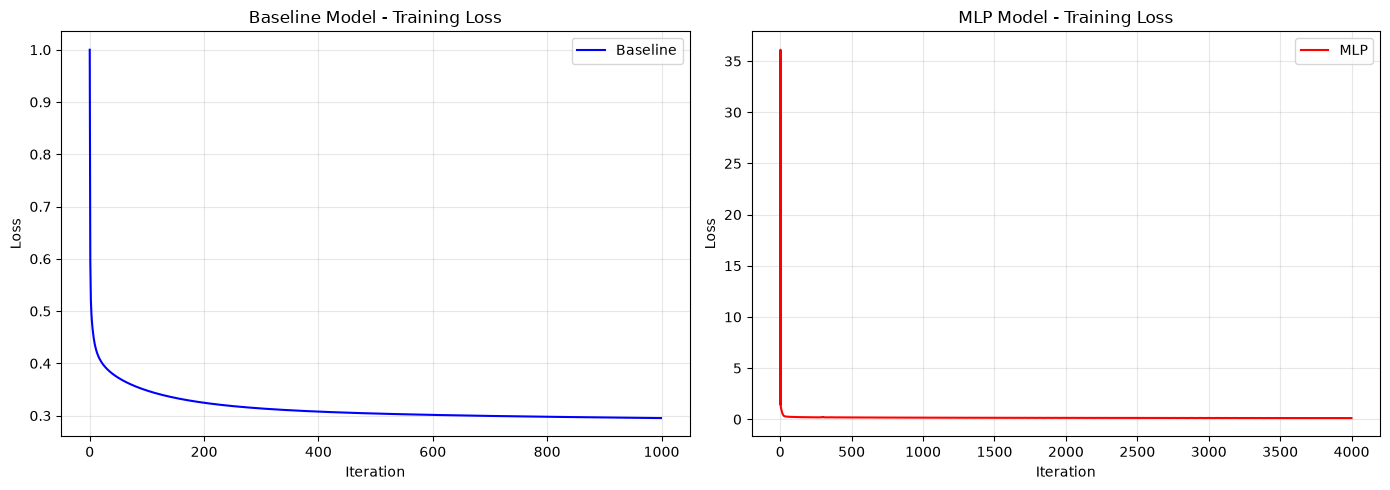

In [24]:
# 1. Training loss curves
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(baseline_model.loss_history, label='Baseline', color='blue')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Baseline Model - Training Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(mlp_model.loss_history, label='MLP', color='red')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('MLP Model - Training Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

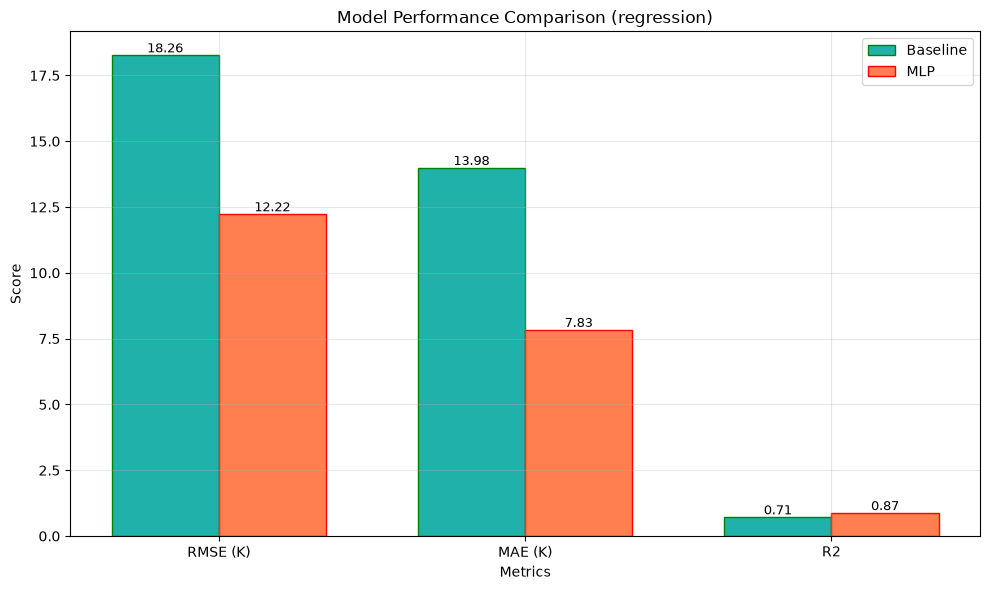

In [39]:
# 2. Performance comparison bar chart
plt.figure(figsize=(10, 6))

metric_names = ['RMSE (K)', 'MAE (K)', 'R2']
baseline_scores = [baseline_rmse, baseline_mae, baseline_r2]
mlp_scores = [mlp_rmse, mlp_mae, mlp_r2]

x = np.arange(len(metric_names))
width = 0.35

bars1 = plt.bar(x - width/2, baseline_scores, width, label='Baseline', color='lightseagreen', edgecolor='green')
bars2 = plt.bar(x + width/2, mlp_scores, width, label='MLP', color='coral', edgecolor='red')

# annotate values (RMSE/MAE and R2 sit on very different scales)
for bars in (bars1, bars2):
    for b in bars:
        plt.text(b.get_x() + b.get_width()/2, b.get_height(),
                 f'{b.get_height():.2f}', ha='center', va='bottom', fontsize=9)

plt.xlabel('Metrics')
plt.ylabel('Score')
plt.title('Model Performance Comparison (regression)')
plt.xticks(x, metric_names)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Section 7: Analysis and Discussion

Write your analysis (minimum 200 words)

In [26]:
analysis_text = """
The MLP did a lot better than the linear baseline on this dataset. The linear
regression got a test R-squared of 0.71 (RMSE 18.26 K, MAE 13.98 K), while the
tuned MLP with architecture 81-128-64-1 got R-squared 0.87 (RMSE 12.23 K,
MAE 7.83 K). So the error dropped by about 6 K and the model explained a lot more
of the variance, which is a good improvement considering the critical temperature
ranges from 0 to 185 K.

I think the MLP works better here because the link between the 81 features and the
critical temperature isn't linear. The hidden layers with ReLU can combine the
features in more complex ways, but the linear model can only draw one straight
hyperplane, so it misses a lot of the pattern.

The MLP took longer to train. The baseline finished quicker 
(lr 0.01, 1000 iterations), but the MLP (lr 0.05, 4000 iterations)
took longer because each step has to go forward and
backward through two hidden layers.

The main challenge was numerical stability: standardising both the features and the
target was essential, and at learning rate 0.05 the loss spikes briefly before
settling into smooth convergence. The simple linear model already got 0.71, 
which is a high bar.
"""

print(f"Analysis word count: {len(analysis_text.split())} words")
if len(analysis_text.split()) < 200:
    print("\u26a0\ufe0f  Warning: Analysis should be at least 200 words")
else:
    print("\u2713 Analysis meets word count requirement")

Analysis word count: 205 words
✓ Analysis meets word count requirement


---
---

## ⭐ REQUIRED: Structured Output Function

### **DO NOT MODIFY THE STRUCTURE BELOW**

This function will be called by the auto-grader. Fill in all values accurately based on your actual results.


⭐⭐⭐ REQUIRED: Structured Output Function ⭐⭐⭐

### 🚨 CRITICAL - READ CAREFULLY 🚨

1. **Fill in ALL fields** - Missing fields = 0 marks
2. **Use your actual values** - Not 0 or empty strings
3. **This cell MUST be executed** - We need the output!
4. **Print the results** - Auto-grader needs to see output!


**DO NOT:**
- Leave any field as 0, 0.0,
- Clear outputs before submission
- Modify the structure


"**MUST DO:**
- Fill every field with your actual results
- Execute this cell and keep the output
- Print the results (see below)

In [30]:
def get_assignment_results():
    '''
    CRITICAL: Fill ALL fields with your actual results!
    Missing fields will result in 0 marks for that section.
    '''

    results = {
        # ===== Dataset Information (1 mark) =====
        'dataset_name': dataset_name,  # MUST fill
        'dataset_source': dataset_source,  # MUST fill
        'n_samples': n_samples,  # MUST be ≥500
        'n_features': n_features,  # MUST be ≥5
        'problem_type': problem_type,  # MUST fill
        'problem_statement': problem_statement,  # MUST be ≥50 words
        'primary_metric': primary_metric,  # MUST fill
        'metric_justification': metric_justification,  # MUST be ≥30 words
        'train_samples': train_samples,
        'test_samples': test_samples,
        'train_test_ratio': train_test_ratio,

        # ===== Baseline Model (3 marks) =====
        'baseline_model': {
            'model_type': 'linear_regression',  # 'linear_regression', 'logistic_regression', 'softmax_regression'
            'learning_rate': baseline_model.lr,  # Your learning rate
            'n_iterations': baseline_model.n_iterations,  # Your iterations

            # CRITICAL: These MUST be filled!
            'initial_loss': baseline_initial_loss,  # MUST NOT be 0
            'final_loss': baseline_final_loss,  # MUST NOT be 0
            'training_time_seconds': baseline_training_time,  # MUST NOT be 0
            'loss_decreased': baseline_final_loss < baseline_initial_loss,  # Auto-calculated

            # Metrics - Fill based on your problem type
            'test_accuracy': 0.0 if problem_type == 'regression' else baseline_acc,
            'test_precision': 0.0 if problem_type == 'regression' else baseline_prec,
            'test_recall': 0.0 if problem_type == 'regression' else baseline_rec,
            'test_f1': 0.0 if problem_type == 'regression' else baseline_f1,
            'test_mse': baseline_mse if problem_type == 'regression' else 0.0,
            'test_rmse': baseline_rmse if problem_type == 'regression' else 0.0,
            'test_mae': baseline_mae if problem_type == 'regression' else 0.0,
            'test_r2': baseline_r2 if problem_type == 'regression' else 0.0,
        },

        # ===== MLP Model (4 marks) =====
        'mlp_model': {
            'architecture': mlp_architecture,  # MUST have ≥3 elements
            'n_hidden_layers': len(mlp_architecture) - 2 if len(mlp_architecture) > 0 else 0,
            'learning_rate': mlp_model.lr,
            'n_iterations': mlp_model.n_iterations,

            # CRITICAL: These MUST be filled!
            'initial_loss': mlp_initial_loss,  # MUST NOT be 0
            'final_loss': mlp_final_loss,  # MUST NOT be 0
            'training_time_seconds': mlp_training_time,  # MUST NOT be 0
            'loss_decreased': mlp_final_loss < mlp_initial_loss,  # Auto-calculated

            # Metrics
            'test_accuracy': 0.0 if problem_type == 'regression' else mlp_acc,
            'test_precision': 0.0 if problem_type == 'regression' else mlp_prec,
            'test_recall': 0.0 if problem_type == 'regression' else mlp_rec,
            'test_f1': 0.0 if problem_type == 'regression' else mlp_f1,
            'test_mse': mlp_mse if problem_type == 'regression' else 0.0,
            'test_rmse': mlp_rmse if problem_type == 'regression' else 0.0,
            'test_mae': mlp_mae if problem_type == 'regression' else 0.0,
            'test_r2': mlp_r2 if problem_type == 'regression' else 0.0,
        },

        # ===== Analysis (2 marks) =====
        'analysis': analysis_text,
        'analysis_word_count': len(analysis_text.split()),
    }

    return results

# ===== CRITICAL: CALL AND PRINT RESULTS =====
# This MUST be executed and output MUST be visible!
import json
results = get_assignment_results()
print(json.dumps(results, indent=2))

# ===== Validation =====
print("\n" + "="*60)
print("VALIDATION CHECK")
print("="*60)


errors = []

if results['n_samples'] < 500:
    errors.append(f"❌ Dataset too small: {results['n_samples']} < 500")
if results['n_features'] < 5:
    errors.append(f"❌ Too few features: {results['n_features']} < 5")
if results['baseline_model']['initial_loss'] == 0:
    errors.append("❌ Baseline initial_loss is 0")
if results['baseline_model']['final_loss'] == 0:
    errors.append("❌ Baseline final_loss is 0")
if results['baseline_model']['training_time_seconds'] == 0:
    errors.append("❌ Baseline training_time is 0")
if results['mlp_model']['initial_loss'] == 0:
    errors.append("❌ MLP initial_loss is 0")
if results['mlp_model']['final_loss'] == 0:
    errors.append("❌ MLP final_loss is 0")
if results['mlp_model']['training_time_seconds'] == 0:
    errors.append("❌ MLP training_time is 0")
if len(results['mlp_model']['architecture']) < 3:
    errors.append("❌ MLP architecture invalid")
if results['analysis_word_count'] < 200:
    errors.append(f"❌ Analysis too short: {results['analysis_word_count']} < 200 words")

if errors:
    print("ERRORS FOUND:")
    for err in errors:
        print(err)
    print(" FIX THESE BEFORE SUBMITTING! ")
else:
    print("✅ All validation checks passed!")
    print("✅ Ready to submit!")
    print("Next steps:")
    print("1. Kernel → Restart & Clear Output")
    print("2. Kernel → Restart & Run All")
    print("3. Verify this output is visible")
    print("4. Save notebook")
    print("5. Rename as: YourStudentID_assignment.ipynb")
    print("6. Submit to LMS")

{
  "dataset_name": "Superconductivity Data",
  "dataset_source": "UCI ML Repository (id=464)",
  "n_samples": 21263,
  "n_features": 81,
  "problem_type": "regression",
  "problem_statement": "\nThis dataset has 81 features derived from the elemental composition of about 21,000\nsuperconducting materials. The goal is to predict the critical temperature (Tc) - the\ntemperature below which the material becomes superconducting. Good predictions can\nspeed up materials research by helping narrow down promising chemical compositions for\nhigh-temperature superconductors before actually synthesizing and testing them in a lab.\n",
  "primary_metric": "rmse",
  "metric_justification": "\nThis is a regression task with the target measured in Kelvin, so RMSE reports the\ntypical prediction error in the same physical units, which is directly interpretable\nfor materials scientists. It also penalises large errors more heavily than MAE, which\nmatters because badly mis-estimating Tc would waste ex

## Test Your Output

Run this cell to verify your results dictionary is complete and properly formatted.

In [ ]:
# Test the output
import json

try:
    results = get_assignment_results()

    print("="*70)
    print("ASSIGNMENT RESULTS SUMMARY")
    print("="*70)
    print(json.dumps(results, indent=2))
    print("\n" + "="*70)


    # Check for missing values
    missing = []
    def check_dict(d, prefix=""):
        for k, v in d.items():
            if isinstance(v, dict):
                check_dict(v, f"{prefix}{k}.")
            elif (v == 0 or v == "" or v == 0.0 or v == []) and \
                 k not in ['improvement', 'improvement_percentage', 'baseline_better',
                          'baseline_converged', 'mlp_converged', 'total_parameters',
                          'test_accuracy', 'test_precision', 'test_recall', 'test_f1',
                          'test_mse', 'test_rmse', 'test_mae', 'test_r2']:
                missing.append(f"{prefix}{k}")

    check_dict(results)

    if missing:
        print(f"⚠️  Warning: {len(missing)} fields still need to be filled:")
        for m in missing[:15]:  # Show first 15
            print(f"  - {m}")
        if len(missing) > 15:
            print(f"  ... and {len(missing)-15} more")
    else:
        print("✅ All required fields are filled!")
        print("\n🎉 You're ready to submit!")
        print("\nNext steps:")
        print("1. Kernel → Restart & Clear Output")
        print("2. Kernel → Restart & Run All")
        print("3. Verify no errors")
        print("4. Save notebook")
        print("5. Rename as: YourStudentID_assignment.ipynb")
        print("6. Submit to LMS")

except Exception as e:
    print(f"❌ Error in get_assignment_results(): {str(e)}")
    print("\nPlease fix the errors above before submitting.")

ASSIGNMENT RESULTS SUMMARY
{
  "dataset_name": "Superconductivity Data",
  "dataset_source": "UCI ML Repository (id=464)",
  "n_samples": 21263,
  "n_features": 81,
  "problem_type": "regression",
  "problem_statement": "\nWe predict the critical temperature (Tc, in Kelvin) at which a material becomes\nsuperconducting, using 81 numerical features derived from its elemental composition\n(aggregate statistics of atomic mass, ionization energy, atomic radius, density,\nelectron affinity, fusion heat, thermal conductivity and valence). Reliable Tc\nprediction lets researchers screen candidate materials computationally instead of\nsynthesising and testing each one in the lab, accelerating the search for\nhigh-temperature superconductors that would not require costly extreme cooling.\n",
  "primary_metric": "rmse",
  "metric_justification": "\nThis is a regression task with the target measured in Kelvin, so RMSE reports the\ntypical prediction error in the same physical units, which is direc

---

## 📤 Before Submitting - Final Checklist

- [ ] **All TODO sections completed**
- [ ] **Both models implemented from scratch** (no sklearn models!)
- [ ] **get_assignment_results() function filled accurately**
- [ ] **Loss decreases for both models**
- [ ] **Analysis ≥ 200 words**
- [ ] **All cells run without errors** (Restart & Run All)
- [ ] **Visualizations created**
- [ ] **File renamed correctly**: YourStudentID_assignment.ipynb

---

**Good luck! **